In [26]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [27]:
# 문제 1: 고객별 RFM 점수를 계산하고, 고객을 'VIP', '우수고객', '일반고객', '이탈위험고객'으로 분류하세요.
# 시각화: 바 차트

# 비즈니스 목적: 고객을 가치에 따라 세분화하고, 그룹별로 맞춤형 마케팅을 진행하여 고객 관계를 강화합니다.

# 출력 결과를 보고 코딩하세요



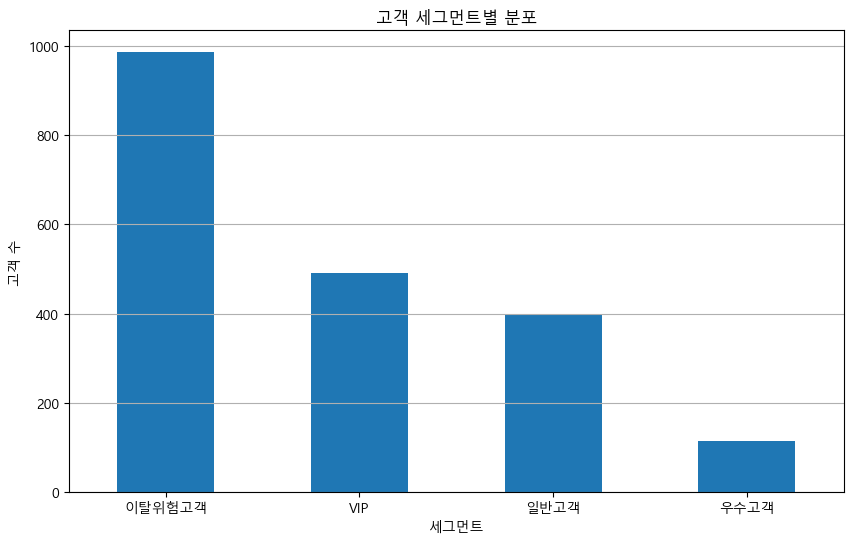



In [28]:
# 문제 2: 고객의 생애 가치(LTV)를 간단하게 계산하여 상위 10명의 고객을 찾으세요.
# 비즈니스 목적: 장기적으로 회사에 가장 큰 가치를 제공하는 핵심 고객을 식별하고, 이들에게 차별화된 혜택을 제공하여 관계를 유지합니다.

# 출력 결과를 보고 코딩하세요



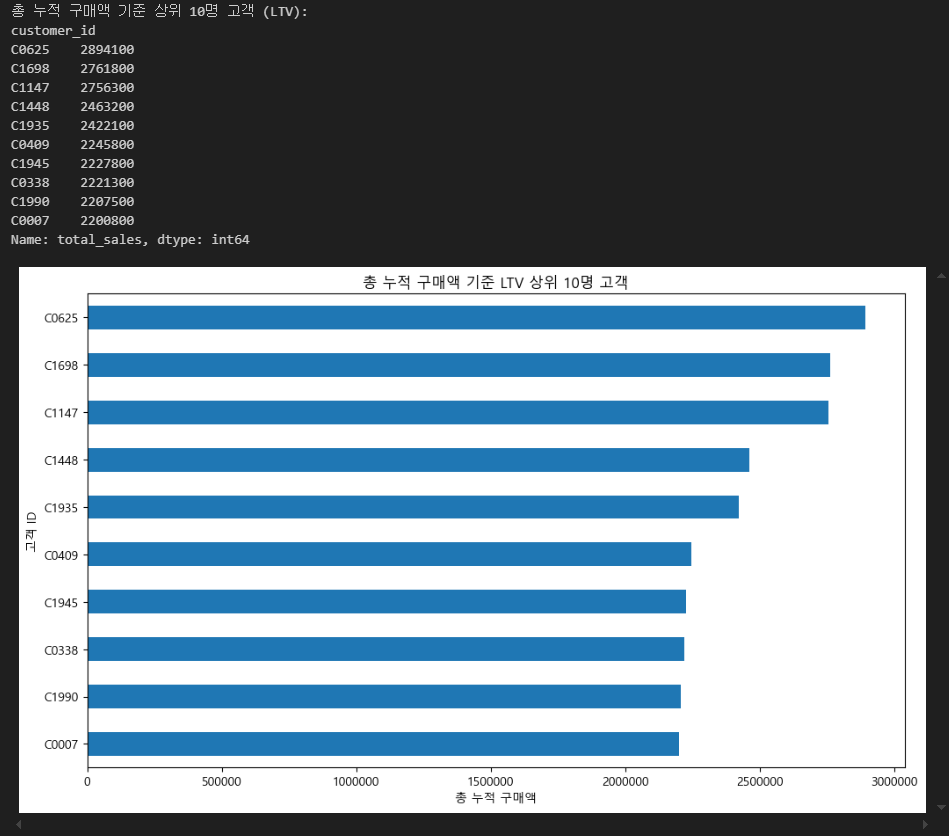



총 누적 구매액 기준 상위 10명 고객 (LTV):
customer_id
C0625    2894100
C1698    2761800
C1147    2756300
C1448    2463200
C1935    2422100
C0409    2245800
C1945    2227800
C0338    2221300
C1990    2207500
C0007    2200800
Name: total_sales, dtype: int64


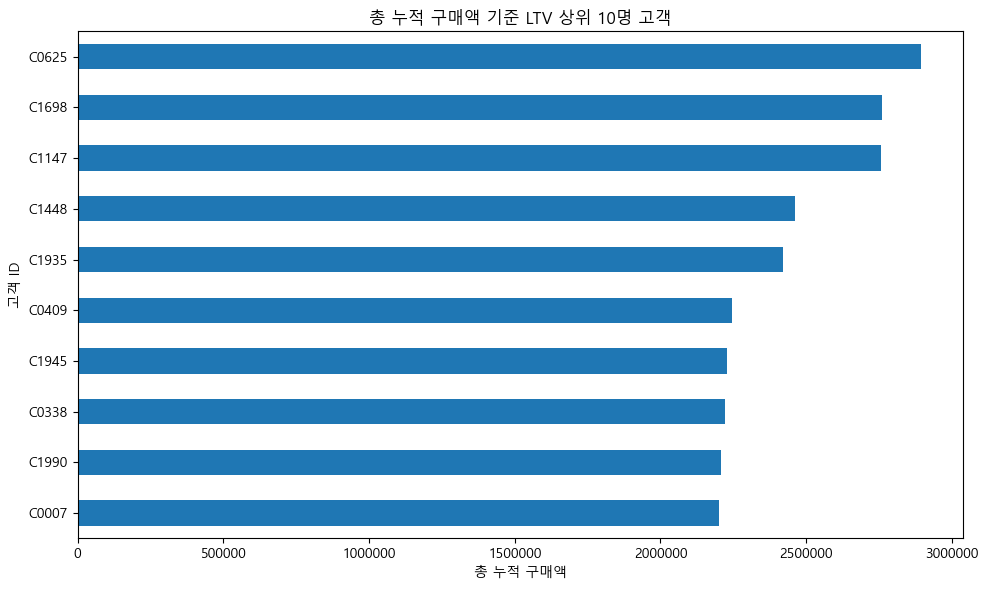

In [29]:
# ✅ 문제 2: 고객의 생애 가치(LTV)를 계산하여 상위 10명의 고객을 찾는 코드

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # ✅ 눈금 단위 조정을 위해 import

# ▶ 고객별 총 누적 구매액(Lifetime Value, LTV) 계산
# groupby('customer_id'): 고객별로 묶기
# ['total_sales']: 구매금액 컬럼 선택
# sum(): 고객별 총합 계산
# sort_values(ascending=False): 내림차순 정렬로 상위 고객을 찾음
# head(10): 상위 10명만 추출
ltv = df.groupby('customer_id')['total_sales'].sum().sort_values(ascending=False).head(10)

# ▶ 계산된 결과 출력
print("총 누적 구매액 기준 상위 10명 고객 (LTV):")
print(ltv)

# ▶ 그래프 크기 설정 (가로 10, 세로 6 인치)
plt.figure(figsize=(10,6))

# ▶ ltv를 정렬하여 가로 막대 그래프로 표시
# kind='barh': 가로 막대 그래프
# sort_values(): 하단부터 상단으로 순서대로 표시되게 정렬
ax = ltv.sort_values().plot(kind='barh')

# ▶ 그래프 제목 설정
plt.title('총 누적 구매액 기준 LTV 상위 10명 고객')

# ▶ x, y 축 라벨 설정
plt.xlabel('총 누적 구매액')
plt.ylabel('고객 ID')

# ▶ x축 눈금 형식 지정
# 천단위 콤마를 없애기 위해 단순히 정수형으로 포맷 지정
# 이전에는 f'{int(x):,}' (콤마 포함)이었지만, 지금은 f'{int(x)}' 로 변경
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}'))

# ▶ x축 눈금 간격 설정
# 500,000 단위로 눈금이 표시되도록 설정 (0, 500000, 1000000, ...)
ax.xaxis.set_major_locator(ticker.MultipleLocator(500000))

# ▶ 눈금 회전 없이 표시
plt.xticks(rotation=0)

# ▶ 그래프 여백 자동 조정
plt.tight_layout()

# ▶ 그래프 출력
plt.show()


In [30]:
# 문제 3: 이탈 고객(가정: 마지막 구매 후 180일 이상 경과)의 이탈 직전 30일간 구매 패턴을 분석하세요.
# - 분석 기준일을 마지막 주문일 다음 날로 설정
# 비즈니스 목적: 고객이 이탈하기 전에 보이는 공통적인 행동 패턴을 파악하여, 유사한 패턴을 보이는 고객에게 선제적으로 이탈 방지 캠페인을 진행합니다.

# 출력 결과를 보고 코딩하세요




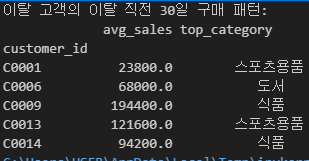


In [31]:
# ✅ 문제 3: 이탈 고객(180일 이상 구매 없음)의 이탈 직전 30일 구매 패턴 분석

# ▶ 각 고객별 마지막 주문일(last purchase date) 계산
# groupby('customer_id'): 고객별 묶음
# ['order_date'].max(): 각 고객의 가장 최근 주문 날짜 추출
last_purchase = df.groupby('customer_id')['order_date'].max()

# ▶ 전체 데이터 중에서 분석 기준일 기준으로 180일 이상 경과한 고객을 '이탈 고객'으로 정의
# df['order_date'].max(): 전체 데이터의 마지막 주문일을 전체 기준일로 설정
analysis_date = df['order_date'].max()  # 예: 2023-12-31 같은 전체 기준
churn_threshold = timedelta(days=180)   # 180일 설정

# ▶ 마지막 구매일 + 180일이 전체 기준일보다 이전인 고객 = 이탈 고객
churn_customers = last_purchase[last_purchase + churn_threshold < analysis_date].index

# ▶ 이탈 고객만 필터링하여 새로운 데이터프레임 생성
churn_df = df[df['customer_id'].isin(churn_customers)]

# ▶ 이탈 고객별로 “이탈 직전 30일간의 구매 내역”만 추출
# last_purchase[cust] - timedelta(days=30): 고객의 마지막 구매일 기준 30일 전 날짜
recent_30_df = churn_df[
    churn_df.apply(lambda x: (last_purchase[x['customer_id']] - timedelta(days=30)) <= x['order_date'] <= last_purchase[x['customer_id']], axis=1)
]

# ▶ 이탈 직전 30일간의 고객별 평균 구매금액 계산
# mean(): 평균값 계산
avg_sales = recent_30_df.groupby('customer_id')['total_sales'].mean()

# ▶ 이탈 직전 30일간 가장 많이 구매한 상품 카테고리 추출
# value_counts().idxmax(): 최빈값(가장 많이 구매한 카테고리) 반환
top_category = recent_30_df.groupby('customer_id')['category'].agg(lambda x: x.value_counts().idxmax())

# ▶ 평균 구매금액(avg_sales)와 주요 카테고리(top_category)를 하나의 데이터프레임으로 결합
churn_pattern = pd.DataFrame({
    'avg_sales': avg_sales,
    'top_category': top_category
})

# ▶ 이탈 고객의 이탈 직전 30일 구매 패턴 출력
print("이탈 고객의 이탈 직전 30일 구매 패턴:")
print(churn_pattern.head())  # 상위 일부 고객만 출력


이탈 고객의 이탈 직전 30일 구매 패턴:
             avg_sales top_category
customer_id                        
C0001          23800.0        스포츠용품
C0006          68000.0           도서
C0009         194400.0           식품
C0013         121600.0        스포츠용품
C0014          94200.0          화장품


In [32]:
# 문제 4: 연령대를 10세 단위로 나누고, 각 연령대별로 가장 선호하는 상품 카테고리를 찾으세요.
# 시각화: 누적 바 차트

# 비즈니스 목적: 연령대별로 선호하는 상품군이 다르다는 가설을 검증하고, 연령 타겟 마케팅 및 상품 소싱 전략에 활용합니다.

# 출력 결과를 보고 코딩하세요

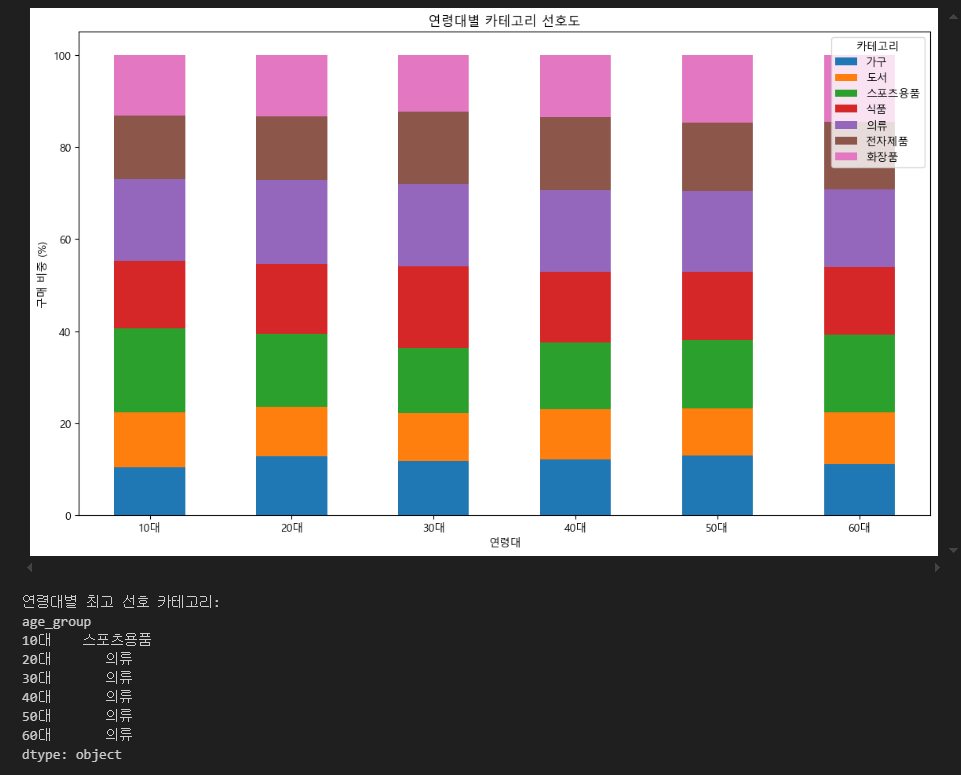





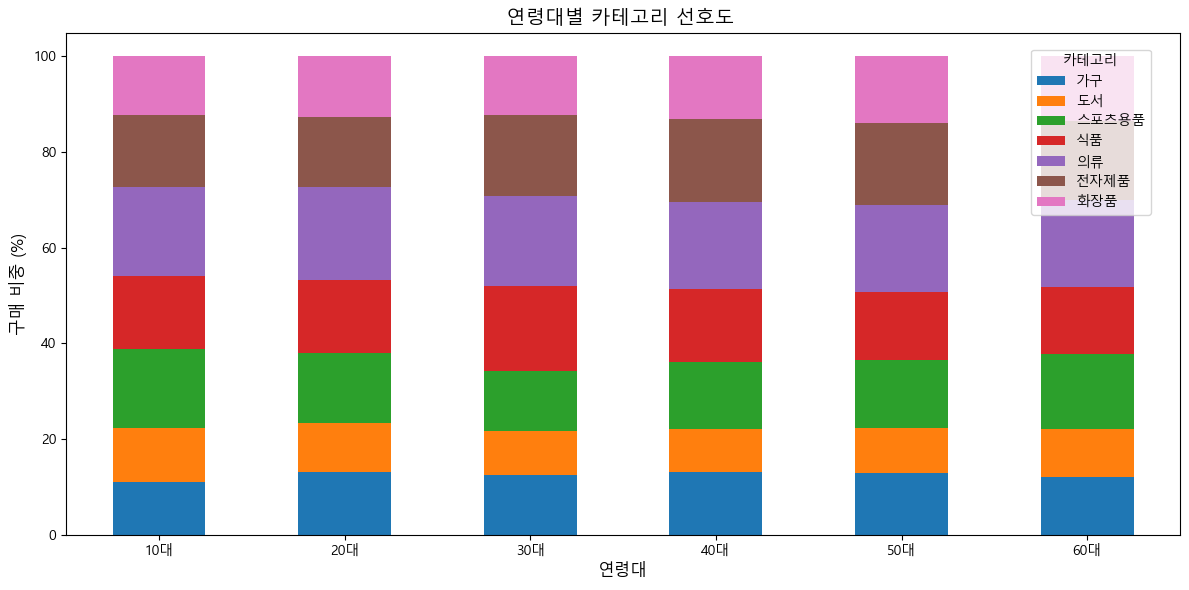

연령대별 최고 선호 카테고리:
age_group
10대    의류
20대    의류
30대    의류
40대    의류
50대    의류
60대    의류
dtype: object


In [33]:
# ----------------------------
# 연령대별 카테고리 선호도 (70대 제외)
# 그래프 먼저 → 그다음 print()
# ----------------------------

import matplotlib.pyplot as plt  # matplotlib: 데이터 시각화를 위한 라이브러리 불러오기

# 1️⃣ 연령대(age_group) 컬럼 생성 (10세 단위)
df['age_group'] = (df['age'] // 10 * 10).astype(int).astype(str) + '대'
# (무엇을 하는지) 나이를 10으로 나눈 몫에 10을 곱해 10단위 구간(예: 23 → 20)을 만든 뒤 '대'를 붙임
# (왜 필요한가) 연령별이 아닌 ‘연령대별’ 분석을 위해 나이를 범주형으로 변환
# (다른 코드와의 결합) 이후 groupby(['age_group','category'])로 집계할 때 기준 컬럼이 됨

# 2️⃣ 70대 이상 데이터 제거
df = df[df['age_group'] != '70대']
# (무엇을 하는지) age_group이 '70대'인 행을 제외
# (왜 필요한가) 시각화 및 분석 결과에서 70대를 제외해 달라는 요구사항 반영
# (다른 코드와의 결합) 이후 집계와 그래프에는 10~60대만 포함됨

# 3️⃣ 연령대별·카테고리별 총매출 합계 계산
age_category_sales = df.groupby(['age_group', 'category'])['total_sales'].sum().unstack(fill_value=0)
# (무엇을 하는지) 연령대와 카테고리별로 총매출(total_sales)을 합산하고, 카테고리를 열로 펼침
# (왜 필요한가) 연령대별 카테고리 매출 구조를 확인하기 위한 기반 데이터 생성

# 4️⃣ 연령대별 카테고리 비중(%) 계산
age_category_pct = age_category_sales.div(age_category_sales.sum(axis=1), axis=0) * 100
# (무엇을 하는지) 각 연령대(행) 기준으로 전체 대비 각 카테고리 비율(%) 계산
# (왜 필요한가) 절대값보다 ‘비율’을 보는 게 연령대 간 비교에 유리함

# 5️⃣ 연령대별 최고 선호 카테고리(비율이 가장 높은 항목) 구하기
top_category_by_age = age_category_pct.idxmax(axis=1)
# (무엇을 하는지) 각 연령대별로 가장 비중이 높은 카테고리 이름을 반환
# (다른 코드와의 결합) 아래 print()에서 결과를 출력하여 비즈니스 인사이트 도출

# ----------------------------
# 시각화 (그래프 먼저 표시)
# ----------------------------
plt.figure(figsize=(12, 6))  # 그래프 크기 설정 (가로 12인치, 세로 6인치)
# (왜 필요한가) 연령대별 카테고리 수가 많으므로 기본 크기보다 넓게 해야 가독성이 확보됨

ax = plt.gca()  # 현재 Axes(좌표 평면) 가져오기
# (무엇을 하는지) 이후 plot 명령이 이 ax에 그려지게 하여 세부 제어 가능하게 함

# 누적 막대 그래프 (stacked bar chart)
age_category_pct.plot(kind='bar', stacked=True, ax=ax)
# (무엇을 하는지) 연령대별로 각 카테고리 비중을 색깔별로 누적하여 표시
# (왜 필요한가) 연령대 내에서 어떤 카테고리가 더 큰 비중을 차지하는지 직관적으로 표현

# 제목과 축 레이블 설정
plt.title('연령대별 카테고리 선호도 ', fontsize=14)
plt.xlabel('연령대', fontsize=12)
plt.ylabel('구매 비중 (%)', fontsize=12)
# (왜 필요한가) 그래프의 의미를 명확히 전달하기 위해 제목과 축 레이블 필수

# X축 레이블을 가로(수평)로 표시
plt.xticks(rotation=0)
# (무엇을 하는지) 연령대 레이블(예: "10대", "20대")이 세로로 표시되지 않게 회전각 0도로 지정

# 범례(legend)를 그래프 안 오른쪽 상단에 표시
plt.legend(title='카테고리', loc='upper right', bbox_to_anchor=(0.98, 0.98))
# (무엇을 하는지) 범례 상자를 그래프 내부 오른쪽 상단에 배치
# (왜 필요한가) 그래프 외부로 나가면 여백이 많아지고 시각적 집중도가 떨어짐

plt.tight_layout()  # 자동 여백 조정
# (무엇을 하는지) 제목, 범례, 축 레이블이 겹치지 않도록 여백을 자동으로 조정
# (다른 코드와의 결합) show() 전에 호출되어야 시각적 배치가 올바르게 반영됨

plt.show()  # 그래프 먼저 출력
# (무엇을 하는지) 지금까지 설정한 그래프를 화면에 표시
# (왜 필요한가) 요청: “그래프가 먼저, print는 그 다음” 순서 유지

# ----------------------------
# 그래프 출력 후 텍스트 결과
# ----------------------------
print("연령대별 최고 선호 카테고리:")
# (무엇을 하는지) 출력 내용의 제목 역할
# (왜 필요한가) print 결과가 어떤 의미인지 바로 이해할 수 있게 함

print(top_category_by_age)
# (무엇을 하는지) 연령대별 1위 카테고리를 표 형식으로 출력
# (다른 코드와의 결합) 위 그래프에서 확인한 색상 비중 결과와 동일해야 함


In [34]:
# 문제 5: 고객의 첫 구매부터 현재까지의 누적 구매액 변화를 고객별로 계산하세요.
# 비즈니스 목적: 고객의 성장 과정을 파악하고, VIP 고객의 성장 패턴을 이해하여 잠재적 VIP 고객을 조기에 발굴하는 데 활용합니다.

# 출력 결과를 보고 코딩하세요


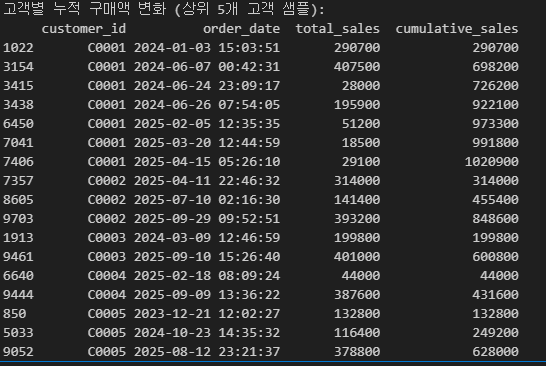




In [35]:
# 나와야 하는거 'customer_id', 'order_date', 'total_sales','cumulative_sales'
# 있는거 'customer_id', 'order_date', 'total_sales'
# 없는거 'cumulative_sales' : 누적 판매량 

# 고객별로 구매 날짜 순서대로 정렬된 새로운 데이터프레임을 만들기
# df_sorted : 고객별로 구매 날짜 순서대로 정렬된 새로운 데이터프레임으로 선언
# sort_values() : Pandas에서 행을 정렬하는 함수 - 값을 기준으로 데이터 정렬
# by=['customer_id', 'order_date'] : 이 열들을 기준으로 정렬해줘
# 먼저 고객별로 묶은 다음 , 고객의 구매 이력을 시간 순서대로 정렬
df_sorted = df.sort_values(by=['customer_id', 'order_date'])


# groupby('customer_id') : 고객별로 데이터 묶기 > 고객 구매 이력을 따로 계산할 수 있게 해주는 단계
# toatal_sales : 누적합을 계산할 대상 열 > 총 구매액 
# cumsum() :누적합을 계산하는 함수
# df_sorted['cumulative_sales']= : 새열 cumulative_sales를 만들어서 결과 저장
df_sorted['cumulative_sales'] = df_sorted.groupby('customer_id')['total_sales'].cumsum()

# 고객별 최종 누적 구매액 추출
# groupby(customer_id)로 고객별로 묶고
# tail(1) : 각 고객의 마지막 구매 행만 가져오기 
# 누적 구매액 중 가장 최신값을 가져오게 됨
# 각 고객의 최종 누적 구매액이 담긴 데이터프레임 생성완료
vip_df = df_sorted.groupby('customer_id').tail(1)

# 누적 구매액 기준 상위 고객 추출
# top_vips = vip_df.sort_values(by='cumulative_sales', ascending=False).head(5)
# - sort_values(by='cumulative_sales', ascending=False): 누적 구매액 기준으로 내림차순 정렬
# - .head(5): 상위 5명만 추출


print("고객별 누적 구매액 변화 (상위 5개 고객 샘플):")

print(df_sorted[['customer_id', 'order_date', 'total_sales', 'cumulative_sales']])




고객별 누적 구매액 변화 (상위 5개 고객 샘플):
     customer_id          order_date  total_sales  cumulative_sales
1022       C0001 2024-01-03 15:03:51       290700            290700
3154       C0001 2024-06-07 00:42:31       407500            698200
3415       C0001 2024-06-24 23:09:17        28000            726200
3438       C0001 2024-06-26 07:54:05       195900            922100
6450       C0001 2025-02-05 12:35:35        51200            973300
...          ...                 ...          ...               ...
3914       C2000 2024-07-31 19:40:44       205000            406900
4404       C2000 2024-09-07 12:51:41       206500            613400
4414       C2000 2024-09-07 22:52:43        98700            712100
7622       C2000 2025-04-29 08:39:11        81000            793100
7774       C2000 2025-05-09 01:41:32        26400            819500

[9845 rows x 4 columns]


In [36]:
df_sorted = df.sort_values(by=['customer_id', 'order_date'])
print(df_sorted)

     order_id customer_id product_id          order_date  quantity payment_id  \
1022  O009026       C0001      P0191 2024-01-03 15:03:51         3  PAY009026   
3154  O009860       C0001      P0082 2024-06-07 00:42:31         5  PAY009860   
3415  O009224       C0001      P0279 2024-06-24 23:09:17         1  PAY009224   
3438  O009387       C0001      P0456 2024-06-26 07:54:05         3  PAY009387   
6450  O005123       C0001      P0440 2025-02-05 12:35:35         1  PAY005123   
...       ...         ...        ...                 ...       ...        ...   
3914  O003811       C2000      P0332 2024-07-31 19:40:44         5  PAY003811   
4404  O009676       C2000      P0312 2024-09-07 12:51:41         5  PAY009676   
4414  O009527       C2000      P0069 2024-09-07 22:52:43         1  PAY009527   
7622  O004839       C2000      P0305 2025-04-29 08:39:11         1  PAY004839   
7774  O009339       C2000      P0330 2025-05-09 01:41:32         2  PAY009339   

      payment_method paymen

In [37]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'order_date', 'quantity',
       'payment_id', 'payment_method', 'payment_status', 'payment_date',
       'product_name', 'category', 'price', 'stock', 'name', 'gender', 'age',
       'join_date', 'city', 'shipping_id', 'shipping_company',
       'shipping_status', 'shipping_start_date', 'shipping_end_date',
       'total_sales', 'age_group'],
      dtype='object')